# Options Pricing -- BSM and Beyond

This notebook implements vanilla option pricing using Black-Scholes-Merton,
computes Greeks, and covers the regulatory treatment under FRTB.

**Regulatory context:**
- FRTB SA -- delta, vega, curvature risk (CRR3 Article 325)
- IFRS 13 -- Level 2 (vanilla with observable vol), Level 3 (exotic)
- EMIR -- OTC options reporting and margining

**Contents:**
1. BSM model
2. European call and put pricing
3. Greeks -- delta, gamma, vega, theta, rho
4. Put-call parity
5. Implied volatility
6. Volatility smile and term structure
7. FRTB SA -- delta, vega, curvature
8. QuantLib implementation

In [ ]:
from quant_risk.setup import base, asset_pricing

np, pd, plt = base()
ois_curve, nss_curve, valuation_date, calendar, ql = asset_pricing()

from scipy.stats import norm
from scipy.optimize import brentq

C1, C2, C3, C4 = '#2E75B6', '#ED7D31', '#A9D18E', '#C00000'
day_count = ql.Actual365Fixed()

OISCurve | currency=EUR | valuation_date=2026-03-24
NSSCurve | currency=EUR | valuation_date=2026-04-30
Valuation date : March 24th, 2026
Calendar       : TARGET


## 1. Black-Scholes-Merton Model

BSM assumes the underlying follows geometric Brownian motion:

$$dS_t = \mu S_t\,dt + \sigma S_t\,dW_t$$

Under risk-neutral measure, $\mu$ is replaced by the risk-free rate $r$.
The closed-form solution for a European call at time $t$:

$$C_t = S_t \cdot e^{-q\tau} \cdot N(d_1) - K \cdot e^{-r\tau} \cdot N(d_2)$$

$$P_t = K \cdot e^{-r\tau} \cdot N(-d_2) - S_t \cdot e^{-q\tau} \cdot N(-d_1)$$

Where $\tau = T - t$ is time to maturity, and:

$$d_1 = \frac{\ln(S_t/K) + (r - q + \frac{1}{2}\sigma^2)\tau}{\sigma\sqrt{\tau}}, \qquad d_2 = d_1 - \sigma\sqrt{\tau}$$



- $S_t$ -- price at time t (considered to be the time of observation = known value)
- $K$ -- strike price
- $r$ -- risk-free rate (OIS)
- $q$ -- dividend yield (0 for non-dividend paying assets)
- $\sigma$ -- implied volatility
- $T$ -- time to expiry in years
- $N(\cdot)$ -- standard normal CDF

**BSM assumptions:**
- Constant volatility (violated in practice -- gives rise to the smile)
- Continuous trading, no transaction costs
- Log-normal returns
- European exercise only

**See comments on $d_1$ and $d_2$ at the end of this notebook.**

In [ ]:
# ── BSM pricer ────────────────────────────────────────────────────────────────

def bsm_d1(S, K, T, r, sigma, q=0.0):
    return (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

def bsm_d2(S, K, T, r, sigma, q=0.0):
    return bsm_d1(S, K, T, r, sigma, q) - sigma * np.sqrt(T)

def bsm_price(S, K, T, r, sigma, q=0.0, option_type='call'):
    """
    Black-Scholes-Merton option price.

    Parameters
    ----------
    S     : spot price
    K     : strike
    T     : time to expiry in years
    r     : risk-free rate (continuous, OIS)
    sigma : implied volatility
    q     : dividend yield (continuous)
    option_type : 'call' or 'put'
    """
    if T <= 0:
        if option_type == 'call':
            return max(S - K, 0)
        return max(K - S, 0)

    d1 = bsm_d1(S, K, T, r, sigma, q)
    d2 = bsm_d2(S, K, T, r, sigma, q)

    if option_type == 'call':
        price = S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)

    return price

The change in option value over a small time step can be approximated by a second-order Taylor expansion:

$$
dV \approx \Delta \, dS + \frac{1}{2}\Gamma \, dS^2 + \text{Vega} \, d\sigma + \Theta \, dt
$$

where

- $\Delta = \frac{\partial V}{\partial S}$  (delta)
- $\Gamma = \frac{\partial^2 V}{\partial S^2}$  (gamma)
- $\text{Vega} = \frac{\partial V}{\partial \sigma}$  (vol sensitivity)
- $\Theta = \frac{\partial V}{\partial t}$  (time decay)

This is a local approximation of the option price dynamics and is the basis of daily PnL attribution used on trading desks.


#### BSM Greeks

**Delta** -- sensitivity to a 1-unit move in the underlying:

$$\Delta_{call} = \frac{\partial C}{\partial S} = e^{-qT} \cdot N(d_1)$$

$$\Delta_{put} = \frac{\partial P}{\partial S} = -e^{-qT} \cdot N(-d_1)$$

**Gamma** -- rate of change of delta per unit move in the underlying (same for call and put):

$$\Gamma = \frac{\partial^2 C}{\partial S^2} = \frac{e^{-qT} \cdot \phi(d_1)}{S \cdot \sigma \cdot \sqrt{T}}$$

**Vega** -- sensitivity to a 1% move in implied volatility (same for call and put):

$$\mathcal{V} = \frac{\partial C}{\partial \sigma} = S \cdot e^{-qT} \cdot \phi(d_1) \cdot \sqrt{T}$$

**Theta** -- change in option price per calendar day:

$$\Theta_{call} = \frac{\partial C}{\partial t} = \frac{-S \cdot e^{-qT} \cdot \phi(d_1) \cdot \sigma}{2\sqrt{T}} - r \cdot K \cdot e^{-rT} \cdot N(d_2) + q \cdot S \cdot e^{-qT} \cdot N(d_1)$$

$$\Theta_{put} = \frac{\partial P}{\partial t} = \frac{-S \cdot e^{-qT} \cdot \phi(d_1) \cdot \sigma}{2\sqrt{T}} + r \cdot K \cdot e^{-rT} \cdot N(-d_2) - q \cdot S \cdot e^{-qT} \cdot N(-d_1)$$

**Rho** -- sensitivity to a 1% move in the risk-free rate:

$$\rho_{call} = \frac{\partial C}{\partial r} = K \cdot T \cdot e^{-rT} \cdot N(d_2)$$

$$\rho_{put} = \frac{\partial P}{\partial r} = -K \cdot T \cdot e^{-rT} \cdot N(-d_2)$$

Where $\phi(\cdot)$ is the standard normal PDF and $N(\cdot)$ is the standard normal CDF.

In [ ]:
def bsm_greeks(S, K, T, r, sigma, q=0.0, option_type='call'):
    """
    BSM Greeks -- delta, gamma, vega, theta, rho.
    """
    d1 = bsm_d1(S, K, T, r, sigma, q)
    d2 = bsm_d2(S, K, T, r, sigma, q)

    phi_d1 = norm.pdf(d1)   # standard normal PDF at d1

    if option_type == 'call':
        delta = np.exp(-q * T) * norm.cdf(d1)
        theta = (
            -S * np.exp(-q * T) * phi_d1 * sigma / (2 * np.sqrt(T))
            - r * K * np.exp(-r * T) * norm.cdf(d2)
            + q * S * np.exp(-q * T) * norm.cdf(d1)
        ) / 365   # per calendar day
        rho = K * T * np.exp(-r * T) * norm.cdf(d2) / 100   # per 1%
    else:
        delta = -np.exp(-q * T) * norm.cdf(-d1)
        theta = (
            -S * np.exp(-q * T) * phi_d1 * sigma / (2 * np.sqrt(T))
            + r * K * np.exp(-r * T) * norm.cdf(-d2)
            - q * S * np.exp(-q * T) * norm.cdf(-d1)
        ) / 365
        rho = -K * T * np.exp(-r * T) * norm.cdf(-d2) / 100

    gamma = np.exp(-q * T) * phi_d1 / (S * sigma * np.sqrt(T))
    vega  = S * np.exp(-q * T) * phi_d1 * np.sqrt(T) / 100   # per 1% vol move

    return {'delta': delta, 'gamma': gamma, 'vega': vega, 'theta': theta, 'rho': rho}


In [ ]:
# ── reference contract -- EuroStoxx 50 ATM call ───────────────────────────────
S0    = 5250.0    # SX5E spot
K     = 5250.0    # ATM
T     = 0.25      # 3M
r     = ois_curve.zero_rate(T) / 100
sigma = 0.165     # 16.5% -- typical SX5E 3M ATM vol
q     = 0.030     # 3% dividend yield
N     = 1000      # number of contracts / multiplier

call_price = bsm_price(S0, K, T, r, sigma, q, 'call')
put_price  = bsm_price(S0, K, T, r, sigma, q, 'put')
greeks_c   = bsm_greeks(S0, K, T, r, sigma, q, 'call')
greeks_p   = bsm_greeks(S0, K, T, r, sigma, q, 'put')

print(f"BSM Option Pricing -- SX5E ATM 3M")
print(f"Spot: {S0:.0f} | Strike: {K:.0f} | T: {T:.2f}Y | Vol: {sigma*100:.1f}% | r: {r*100:.3f}% | q: {q*100:.1f}%")
print(f"\n{'':20} {'Call':>12} {'Put':>12}")
print("-" * 46)
print(f"{'Price':20} {call_price:>12.4f} {put_price:>12.4f}")
print(f"{'Delta':20} {greeks_c['delta']:>12.4f} {greeks_p['delta']:>12.4f}")
print(f"{'Gamma':20} {greeks_c['gamma']:>12.6f} {greeks_p['gamma']:>12.6f}")
print(f"{'Vega (per 1% vol)':20} {greeks_c['vega']:>12.4f} {greeks_p['vega']:>12.4f}")
print(f"{'Theta (per day)':20} {greeks_c['theta']:>12.4f} {greeks_p['theta']:>12.4f}")
print(f"{'Rho (per 1% rate)':20} {greeks_c['rho']:>12.4f} {greeks_p['rho']:>12.4f}")

BSM Option Pricing -- SX5E ATM 3M
Spot: 5250 | Strike: 5250 | T: 0.25Y | Vol: 16.5% | r: 1.979% | q: 3.0%

                             Call          Put
----------------------------------------------
Price                    165.0923     178.4147
Delta                      0.5003      -0.4922
Gamma                    0.000914     0.000914
Vega (per 1% vol)         10.3934      10.3934
Theta (per day)           -0.8572      -1.0023
Rho (per 1% rate)          6.1543      -6.9060


## 2. Put-Call Parity

Put–call parity is a no-arbitrage identity linking European call and put prices with the same strike $K$ and maturity $T$:

$$
C - P = S_0 e^{-qT} - K e^{-rT}
$$

<small>The relation comes from replicating the same terminal payoff of a forward, in two different ways, as shown in the cashflow tables below.

**Synthetic forward - option replication**

| | $t=0$ | $t=T$ |
|--|-------|-------|
| Long call | $-C$ | $(S_T - K)^+$ |
| Short put | $+P$ | $-(K - S_T)^+$ |
| **Net CF** | $P - C$ | $S_T - K$ |

**Synthetic forward – spot and financing replication**

| | $t=0$ | $t=T$ |
|--|-------|-------|
| Borrow $Ke^{-rT}$ | $+Ke^{-rT}$ | $-K$ |
| Long underlying | $-S_0 e^{-qT}$ | $S_T$ |
| **Net CF** | $Ke^{-rT} - S_0 e^{-qT}$ | $S_T - K$ |


In [ ]:
# ── put-call parity verification ─────────────────────────────────────────────
lhs = call_price - put_price
rhs = S0 * np.exp(-q * T) - K * np.exp(-r * T)

print(f"Put-Call Parity Verification")
print(f"C - P         = {lhs:.6f}")
print(f"S*e^(-qT) - K*e^(-rT) = {rhs:.6f}")
print(f"Difference    = {abs(lhs - rhs):.2e}  (numerical precision only)")
print(f"\nForward price implied by parity: {K * np.exp(-r*T) + lhs:.4f}")
print(f"CIP forward price: {S0 * np.exp((r-q)*T):.4f}")

Put-Call Parity Verification
C - P         = -13.322355
S*e^(-qT) - K*e^(-rT) = -13.322355
Difference    = 4.55e-13  (numerical precision only)

Forward price implied by parity: 5210.7723
CIP forward price: 5236.6116


## 3. Greeks -- Sensitivity Analysis

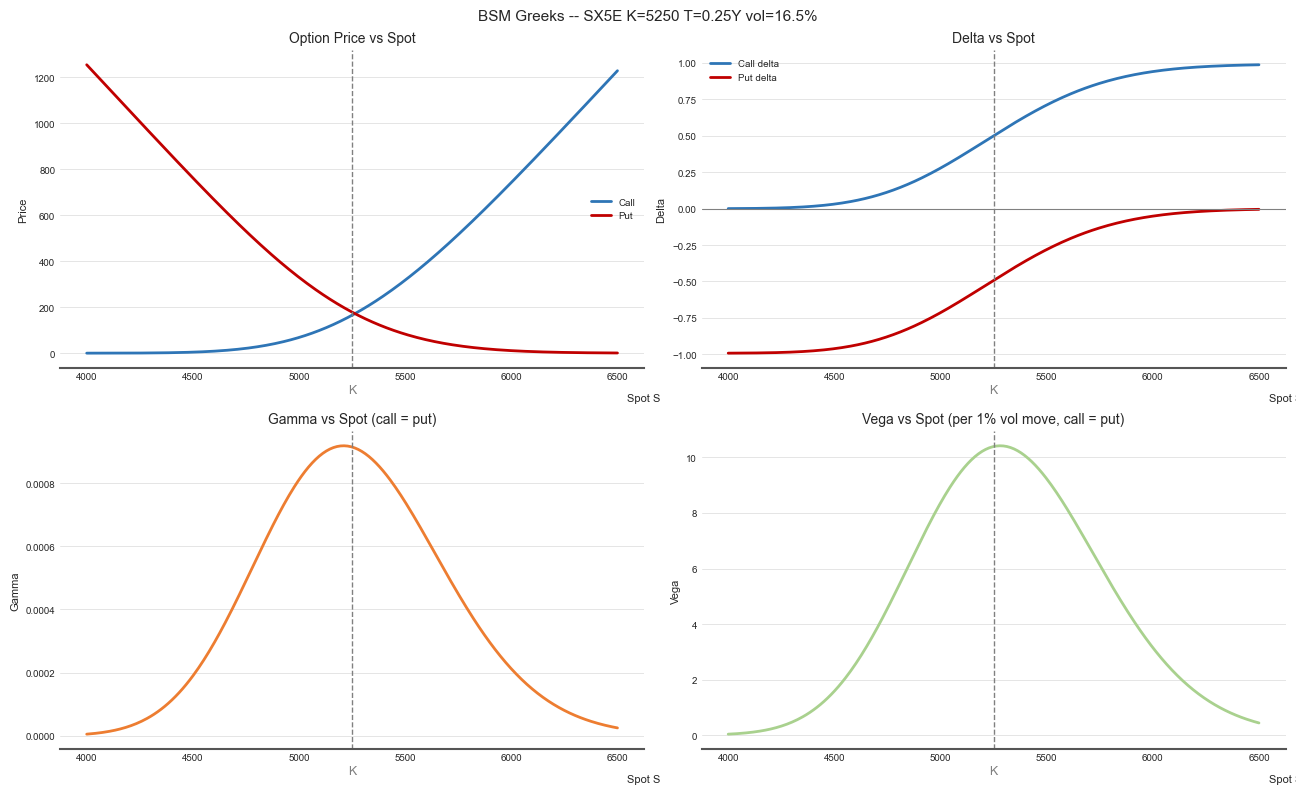

In [ ]:
# ── Greeks profiles across spot ────────────────────────────────────────────────
spots = np.linspace(4000, 6500, 300)

prices_c = [bsm_price(s, K, T, r, sigma, q, 'call') for s in spots]
prices_p = [bsm_price(s, K, T, r, sigma, q, 'put') for s in spots]
deltas_c = [bsm_greeks(s, K, T, r, sigma, q, 'call')['delta'] for s in spots]
deltas_p = [bsm_greeks(s, K, T, r, sigma, q, 'put')['delta'] for s in spots]
gammas   = [bsm_greeks(s, K, T, r, sigma, q, 'call')['gamma'] for s in spots]
vegas    = [bsm_greeks(s, K, T, r, sigma, q, 'call')['vega'] for s in spots]


def mark_strike(ax, K):
    ax.axvline(K, color='grey', linestyle='--', linewidth=1)
    ax.annotate('K',
                xy=(K, 0), xycoords=('data', 'axes fraction'),
                xytext=(0, -12), textcoords='offset points',
                ha='center', va='top', fontsize=9, color='grey')

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0,0].plot(spots, prices_c, color=C1, linewidth=2, label='Call')
axes[0,0].plot(spots, prices_p, color=C4, linewidth=2, label='Put')
mark_strike(axes[0,0], K)
axes[0,0].legend()
axes[0,0].set_title('Option Price vs Spot')
axes[0,0].set_ylabel('Price')

axes[0,1].plot(spots, deltas_c, color=C1, linewidth=2, label='Call delta')
axes[0,1].plot(spots, deltas_p, color=C4, linewidth=2, label='Put delta')
axes[0,1].axhline(0, color='grey', linewidth=0.8)
axes[0,1].legend()
mark_strike(axes[0,1], K)
axes[0,1].set_title('Delta vs Spot')
axes[0,1].set_ylabel('Delta')


axes[1,0].plot(spots, gammas, color=C2, linewidth=2)
mark_strike(axes[1,0], K)
axes[1,0].set_title('Gamma vs Spot (call = put)')
axes[1,0].set_ylabel('Gamma')

# vega profile
axes[1,1].plot(spots, vegas, color=C3, linewidth=2)
mark_strike(axes[1,1], K)
axes[1,1].set_title('Vega vs Spot (per 1% vol move, call = put)')
axes[1,1].set_ylabel('Vega')


for ax in axes.flat:
    ax.set_xlabel('Spot S')
    ax.xaxis.set_label_coords(1.0, -0.08)
    ax.spines['bottom'].set_color('#555555')

plt.suptitle(f'BSM Greeks -- SX5E K={K:.0f} T={T:.2f}Y vol={sigma*100:.1f}%', fontsize=11)
plt.tight_layout()
plt.show()

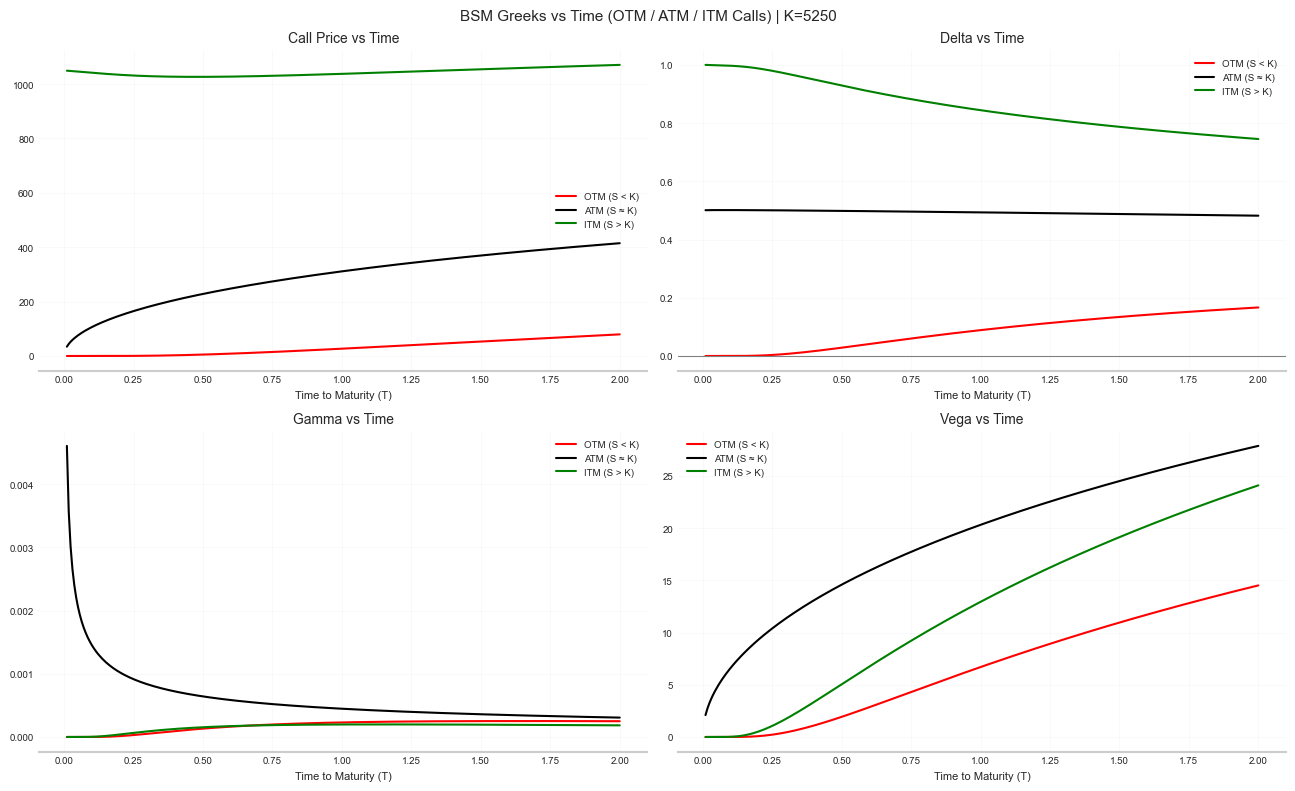

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# fixed params
# ---------------------------
K0 = K
r, q = r, q
sigma = sigma

Ts = np.linspace(0.01, 2.0, 300)

# ---------------------------
# moneyness scenarios
# ---------------------------
S_levels = {
    "OTM (S < K)": 0.8 * S0,
    "ATM (S ≈ K)": S0,
    "ITM (S > K)": 1.2 * S0
}

colors = {
    "OTM (S < K)": "red",
    "ATM (S ≈ K)": "black",
    "ITM (S > K)": "green"
}

# ---------------------------
# storage
# ---------------------------
prices = {}
deltas = {}
gammas = {}
vegas = {}

for label, S in S_levels.items():
    prices[label] = [bsm_price(S, K0, T, r, sigma, q, 'call') for T in Ts]
    deltas[label] = [bsm_greeks(S, K0, T, r, sigma, q, 'call')['delta'] for T in Ts]
    gammas[label] = [bsm_greeks(S, K0, T, r, sigma, q, 'call')['gamma'] for T in Ts]
    vegas[label]  = [bsm_greeks(S, K0, T, r, sigma, q, 'call')['vega'] for T in Ts]

# ---------------------------
# plot
# ---------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# PRICE
for label in S_levels:
    axes[0,0].plot(Ts, prices[label], color=colors[label], label=label)
axes[0,0].set_title("Call Price vs Time")
axes[0,0].legend()

# DELTA
for label in S_levels:
    axes[0,1].plot(Ts, deltas[label], color=colors[label], label=label)
axes[0,1].axhline(0, color='grey', linewidth=0.8)
axes[0,1].set_title("Delta vs Time")
axes[0,1].legend()

# GAMMA
for label in S_levels:
    axes[1,0].plot(Ts, gammas[label], color=colors[label], label=label)
axes[1,0].set_title("Gamma vs Time")
axes[1,0].legend()

# VEGA
for label in S_levels:
    axes[1,1].plot(Ts, vegas[label], color=colors[label], label=label)
axes[1,1].set_title("Vega vs Time")
axes[1,1].legend()

# ---------------------------
# formatting
# ---------------------------
for ax in axes.flat:
    ax.set_xlabel("Time to Maturity (T)")
    ax.grid(alpha=0.2)

plt.suptitle(f"BSM Greeks vs Time (OTM / ATM / ITM Calls) | K={K0:.0f}", fontsize=11)
plt.tight_layout()
plt.show()

### Theta

Option prices can be decomposed into intrinsic value and time value. At any time before maturity:

$$
V(S,t) = \text{Intrinsic Value} + \text{Time Value}
$$

The intrinsic value is what remains at expiry, while time value reflects uncertainty about the future payoff:

* Call: $(S - K)^+$
* Put: $(K - S)^+$

As time approaches maturity ($T \to 0$), the time value collapses and option value converges to intrinsic value:

$$
V \to \max(S - K, 0)
$$


The Greek that measures sensitivity of option value to time is **Theta**:
$
\Theta = \frac{\partial V}{\partial T}
$
. Since time reduces uncertainty, theta is typically negative: option value decreases as maturity approaches. Near expiry, theta becomes increasingly negative because the remaining time value must decay over a very short interval, producing the sharp spike (large negative values) observed as $T \to 0$.


### Theta in BSM and connection to Gamma

In the Black-Scholes-Merton model, theta is:

$$
\Theta =

\frac{S \sigma \phi(d_1)}{2\sqrt{T}}
\cdot r K e^{-rT} N(d_2)

- q S N(d_1)
  $$

The first term is the **time decay term**, the dominant driver of theta.
The second term is the **interest rate carry adjustment**.
The third term is the **dividend yield effect**.


Gamma in Black-Scholes is:

$$
\Gamma = \frac{\partial^2 V}{\partial S^2} = \frac{\phi(d_1)}{S \sigma \sqrt{T}}
$$


This creates a structural relationship between theta and gamma:

$$
\Theta \approx -\frac{1}{2} S^2 \sigma^2 \Gamma + \text{carry terms}
$$


This explains why theta is most negative near-the-money: gamma is maximised when $S \approx K$, so curvature is highest there, leading to faster time decay.



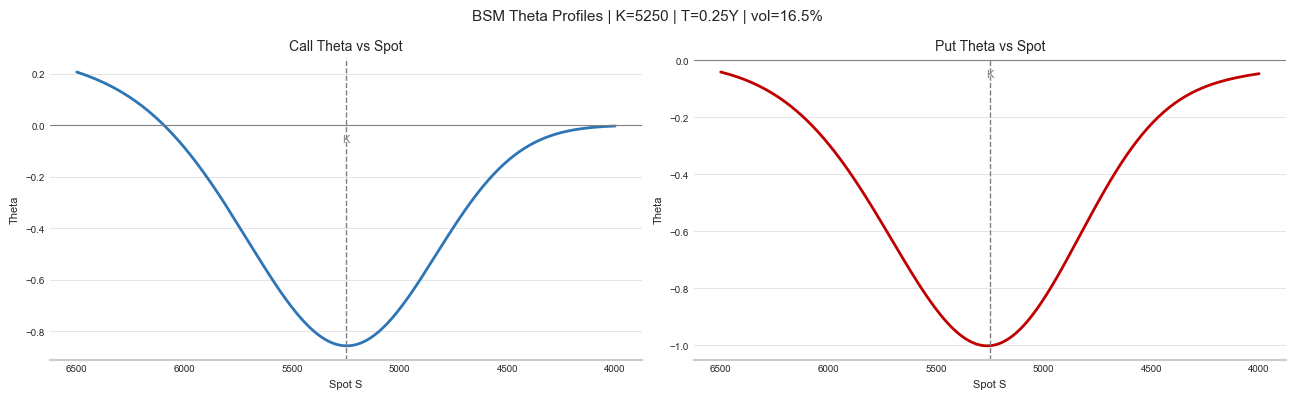

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# assume these already exist:
# spots, K, T, r, sigma, q
# bsm_greeks
# colors C1, C4
# ---------------------------

# choose ONE strike (fix for axvline bug)
K0 = float(K) if np.isscalar(K) else float(np.mean(K))

# ---------------------------
# compute theta
# ---------------------------
theta_c = [
    bsm_greeks(s, K0, T, r, sigma, q, 'call')['theta']
    for s in spots
]

theta_p = [
    bsm_greeks(s, K0, T, r, sigma, q, 'put')['theta']
    for s in spots
]

# ---------------------------
# plot
# ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ===========================
# CALL THETA
# ===========================
axes[0].plot(spots, theta_c, color=C1, linewidth=2)
axes[0].set_title("Call Theta vs Spot")
axes[0].set_xlabel("Spot S")
axes[0].set_ylabel("Theta")

axes[0].axhline(0, color='grey', linewidth=0.8)

axes[0].axvline(K0, color='grey', linestyle='--', linewidth=1)
axes[0].annotate('K',
                 xy=(K0, 0),
                 xytext=(0, -12),
                 textcoords='offset points',
                 ha='center',
                 color='grey')

axes[0].invert_xaxis()  # right side = maturity intuition

# ===========================
# PUT THETA
# ===========================
axes[1].plot(spots, theta_p, color=C4, linewidth=2)
axes[1].set_title("Put Theta vs Spot")
axes[1].set_xlabel("Spot S")
axes[1].set_ylabel("Theta")

axes[1].axhline(0, color='grey', linewidth=0.8)

axes[1].axvline(K0, color='grey', linestyle='--', linewidth=1)
axes[1].annotate('K',
                 xy=(K0, 0),
                 xytext=(0, -12),
                 textcoords='offset points',
                 ha='center',
                 color='grey')

axes[1].invert_xaxis()  # consistent view

# ---------------------------
# formatting
# ---------------------------
plt.suptitle(
    f"BSM Theta Profiles | K={K0:.0f} | T={T:.2f}Y | vol={sigma*100:.1f}%",
    fontsize=11
)

plt.tight_layout()
plt.show()

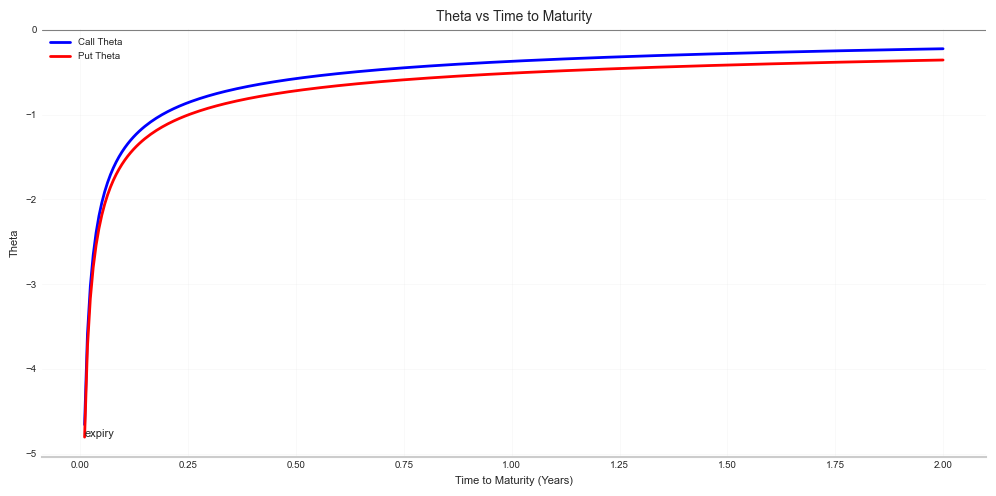

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# fixed inputs
# ---------------------------
S = S0          # current spot
K0 = float(K)   # strike
r, q = r, q
sigma = sigma

# time grid (0.01Y to 2Y for stability)
Ts = np.linspace(0.01, 2.0, 300)

# ---------------------------
# compute theta
# ---------------------------
theta_c = [
    bsm_greeks(S, K0, T, r, sigma, q, 'call')['theta']
    for T in Ts
]

theta_p = [
    bsm_greeks(S, K0, T, r, sigma, q, 'put')['theta']
    for T in Ts
]

# ---------------------------
# plot
# ---------------------------
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(Ts, theta_c, label="Call Theta", color="blue", linewidth=2)
ax.plot(Ts, theta_p, label="Put Theta", color="red", linewidth=2)

ax.axhline(0, color="grey", linewidth=0.8)

ax.set_title("Theta vs Time to Maturity")
ax.set_xlabel("Time to Maturity (Years)")
ax.set_ylabel("Theta")

ax.legend()
ax.grid(alpha=0.2)
ax.text(Ts[0], theta_p[0], "expiry", ha="left")

plt.tight_layout()
plt.show()

## Greek surfaces

$$Greek=f(S,T)$$

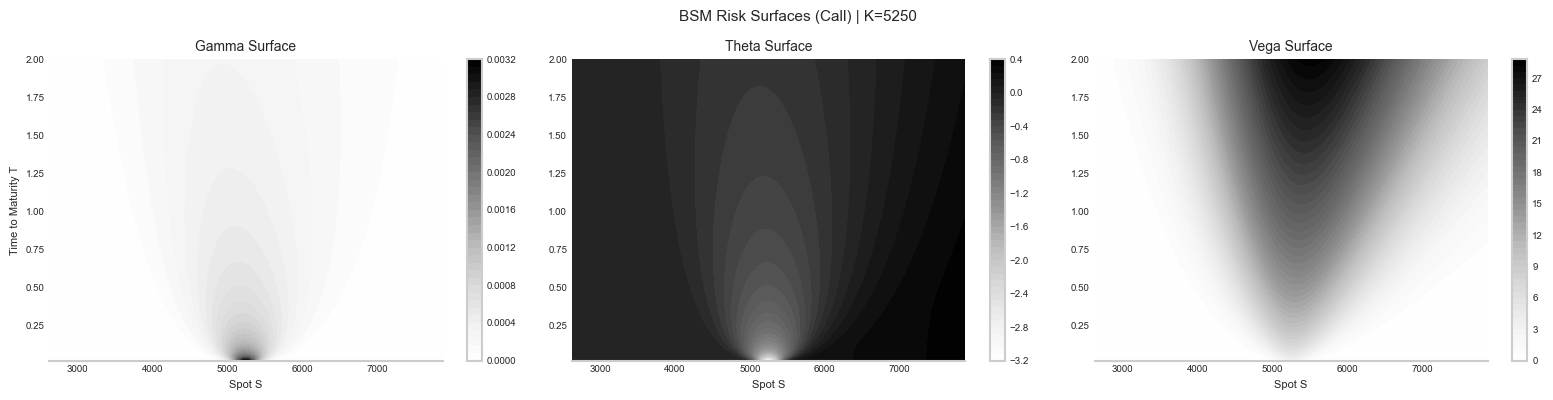

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# grid
S_grid = np.linspace(0.5*S0, 1.5*S0, 80)
T_grid = np.linspace(0.02, 2.0, 80)

S_mesh, T_mesh = np.meshgrid(S_grid, T_grid)

# compute greeks across the grid
Gamma = np.zeros_like(S_mesh)
Theta = np.zeros_like(S_mesh)
Vega  = np.zeros_like(S_mesh)

for i in range(S_mesh.shape[0]):
    for j in range(S_mesh.shape[1]):
        S = S_mesh[i, j]
        T = T_mesh[i, j]

        g = bsm_greeks(S, K, T, r, sigma, q, 'call')

        Gamma[i, j] = g['gamma']
        Theta[i, j] = g['theta']
        Vega[i, j]  = g['vega']


fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Gamma
im0 = axes[0].contourf(S_mesh, T_mesh, Gamma, levels=50)
axes[0].set_title("Gamma Surface")
axes[0].set_xlabel("Spot S")
axes[0].set_ylabel("Time to Maturity T")
plt.colorbar(im0, ax=axes[0])

# Theta
im1 = axes[1].contourf(S_mesh, T_mesh, Theta, levels=50)
axes[1].set_title("Theta Surface")
axes[1].set_xlabel("Spot S")
plt.colorbar(im1, ax=axes[1])

# Vega
im2 = axes[2].contourf(S_mesh, T_mesh, Vega, levels=50)
axes[2].set_title("Vega Surface")
axes[2].set_xlabel("Spot S")
plt.colorbar(im2, ax=axes[2])

plt.suptitle(f"BSM Risk Surfaces (Call) | K={K:.0f}", fontsize=11)
plt.tight_layout()
plt.show()

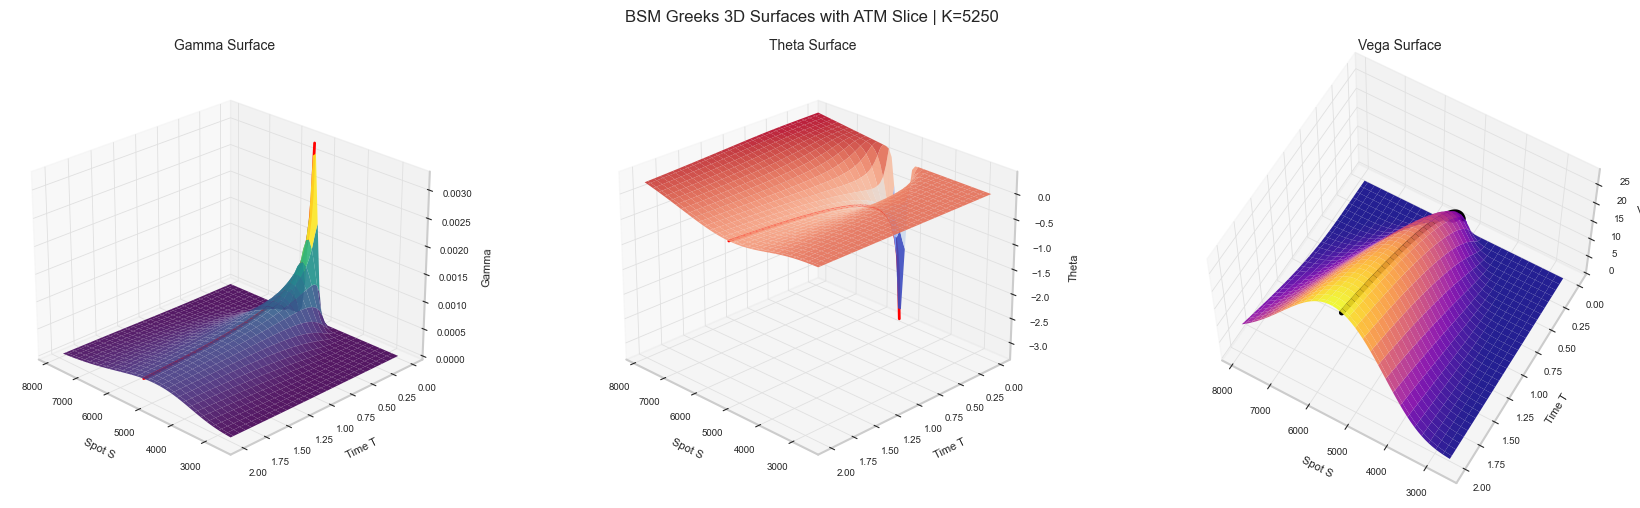

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# ---------------------------
# GRID
# ---------------------------
S_grid = np.linspace(0.5 * S0, 1.5 * S0, 60)
T_grid = np.linspace(0.02, 2.0, 60)

S_mesh, T_mesh = np.meshgrid(S_grid, T_grid)

# ---------------------------
# COMPUTE SURFACES
# ---------------------------
Gamma = np.zeros_like(S_mesh)
Theta = np.zeros_like(S_mesh)
Vega  = np.zeros_like(S_mesh)

for i in range(S_mesh.shape[0]):
    for j in range(S_mesh.shape[1]):
        S = S_mesh[i, j]
        T = T_mesh[i, j]

        g = bsm_greeks(S, K, T, r, sigma, q, 'call')

        Gamma[i, j] = g['gamma']
        Theta[i, j] = g['theta']
        Vega[i, j]  = g['vega']

# ---------------------------
# ATM INTERSECTION CURVE (S = K)
# ---------------------------
T_line = np.linspace(0.02, 2.0, 100)

Gamma_atm = [bsm_greeks(K, K, T, r, sigma, q, 'call')['gamma'] for T in T_line]
Theta_atm = [bsm_greeks(K, K, T, r, sigma, q, 'call')['theta'] for T in T_line]
Vega_atm  = [bsm_greeks(K, K, T, r, sigma, q, 'call')['vega']  for T in T_line]

# ---------------------------
# FIGURE
# ---------------------------
fig = plt.figure(figsize=(18, 5))

def add_strike_plane(ax):
    T_plane = np.linspace(T_grid.min(), T_grid.max(), 2)
    S_plane = np.full((2, 2), K)
    T_plane, _ = np.meshgrid(T_plane, [0, 1])
    S_plane = np.full_like(T_plane, K)
    Z_plane = np.zeros_like(S_plane)

    ax.plot_surface(
        S_plane,
        T_plane,
        Z_plane,
        color='black',
        alpha=0.15,
        linewidth=0,
        shade=False
    )

# ---------------------------
# GAMMA
# ---------------------------
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(S_mesh, T_mesh, Gamma, cmap='viridis', alpha=0.9)

add_strike_plane(ax1)

ax1.plot(
    np.full_like(T_line, K),
    T_line,
    Gamma_atm,
    color='red',
    linewidth=2,
    label='ATM slice'
)

ax1.set_title("Gamma Surface")
ax1.set_xlabel("Spot S")
ax1.set_ylabel("Time T")
ax1.set_zlabel("Gamma")
ax1.view_init(elev=25, azim=135)

# ---------------------------
# THETA
# ---------------------------
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(S_mesh, T_mesh, Theta, cmap='coolwarm', alpha=0.9)

add_strike_plane(ax2)

ax2.plot(
    np.full_like(T_line, K),
    T_line,
    Theta_atm,
    color='red',
    linewidth=2
)

ax2.set_title("Theta Surface")
ax2.set_xlabel("Spot S")
ax2.set_ylabel("Time T")
ax2.set_zlabel("Theta")
ax2.view_init(elev=25, azim=135)

# ---------------------------
# VEGA
# ---------------------------
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(S_mesh, T_mesh, Vega, cmap='plasma', alpha=0.9)

add_strike_plane(ax3)

ax3.plot(
    np.full_like(T_line, K),
    T_line,
    Vega_atm,
    color='black',
    linewidth=4,
)

ax3.set_title("Vega Surface")
ax3.set_xlabel("Spot S")
ax3.set_ylabel("Time T")
ax3.set_zlabel("Vega")
ax3.view_init(elev=60, azim=120)

# ---------------------------
# FINAL
# ---------------------------
plt.suptitle(f"BSM Greeks 3D Surfaces with ATM Slice | K={K:.0f}", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Implied Volatility

Implied volatility is the $\sigma$ that solves:

$$BSM(S, K, T, r, \sigma, q) = P_{market}$$

No closed-form inverse exists -- solved numerically via root-finding
(Newton-Raphson or Brent's method).

In [ ]:
# ── implied volatility solver ─────────────────────────────────────────────────
def implied_vol(market_price, S, K, T, r, q=0.0, option_type='call',
                vol_min=0.001, vol_max=5.0):
    """
    Implied vol via Brent root-finding.
    Finds sigma such that BSM(sigma) = market_price.
    """
    def objective(sigma):
        return bsm_price(S, K, T, r, sigma, q, option_type) - market_price

    try:
        return brentq(objective, vol_min, vol_max, xtol=1e-8)
    
    except ValueError:
        return np.nan


# verify round-trip: price -> implied vol -> price
iv_call = implied_vol(call_price, S0, K, T, r, q, 'call')
iv_put  = implied_vol(put_price,  S0, K, T, r, q, 'put')

print(f"Implied Volatility Round-trip Verification")
print(f"Input vol:        {sigma*100:.4f}%")
print(f"Call implied vol: {iv_call*100:.4f}%")
print(f"Put implied vol:  {iv_put*100:.4f}%")
print(f"Error:            {abs(iv_call - sigma)*10000:.4f}bps")

Implied Volatility Round-trip Verification
Input vol:        16.5000%
Call implied vol: 7.5339%
Put implied vol:  4.2796%
Error:            896.6111bps


## 5. Volatility Smile and Term Structure

In practice, BSM implied volatility is not constant across strikes and tenors.
The **volatility smile** (or skew) captures this:

- **Skew:** "OTM puts" trade at higher implied vol than "OTM calls", particularly in equity indices.

  This reflects persistent downside risk, volatility asymmetry, and
  structural demand for protection. The effect exists in many equity
  underlyings, but is most stable and pronounced at the index level. 

  - asymmetric return distribution (fat left tail)
  - negative correlation between price and volatility (leverage effect)
  - risk premia for bearing downside tail risk

  Structural demand for downside protection reinforces the effect,
  but does not fully explain it.

- **Term structure:** short-dated vol tends to be higher than long-dated vol
  in normal markets (vol mean-reverts). During stress, the curve inverts.

The smile is the most direct evidence that BSM is misspecified.

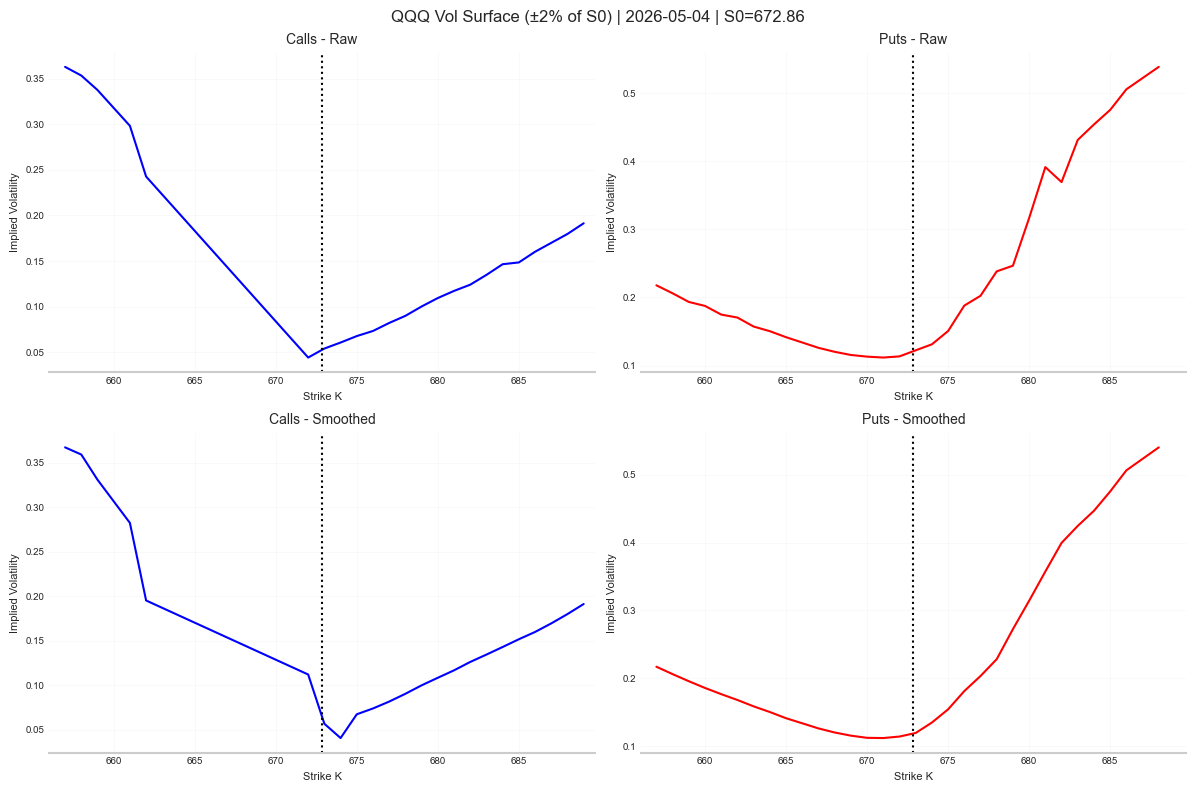

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import yfinance as yf

# ---------------------------
# Load data
# ---------------------------
ticker = yf.Ticker("QQQ")
expiry = ticker.options[0]

calls = ticker.option_chain(expiry).calls.copy()
puts  = ticker.option_chain(expiry).puts.copy()

# ---------------------------
# Spot
# ---------------------------
S0 = ticker.history(period="1y")["Close"].iloc[-1]

# ---------------------------
# PARAMETERS (single source of truth)
# ---------------------------
band = 0.025
lower = (1 - band) * S0
upper = (1 + band) * S0

# ---------------------------
# CLEAN DATAFRAMES (ONLY ONCE)
# ---------------------------
def clean(df):
    df = df.copy()
    df = df[df["impliedVolatility"].notna()]
    df = df[(df["impliedVolatility"] > 0.01) & (df["impliedVolatility"] < 5.0)]
    df = df[(df["strike"] >= lower) & (df["strike"] <= upper)]
    return df.sort_values("strike")

calls_f = clean(calls)
puts_f  = clean(puts)

# ---------------------------
# ARRAYS (ONLY FROM FILTERED DATA)
# ---------------------------
K_c = calls_f["strike"].values
iv_c = calls_f["impliedVolatility"].values

K_p = puts_f["strike"].values
iv_p = puts_f["impliedVolatility"].values

# ---------------------------
# SMOOTHING
# ---------------------------
def smooth(x):
    if len(x) < 5:
        return x
    w = min(7, len(x)//2*2+1)
    return savgol_filter(x, w, polyorder=2)

iv_c_s = smooth(iv_c)
iv_p_s = smooth(iv_p)

# ---------------------------
# PLOT
# ---------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Calls
axes[0,0].plot(K_c, iv_c, color="blue")
axes[0,0].axvline(S0, linestyle=":", color="black")
axes[0,0].set_title("Calls - Raw")

axes[1,0].plot(K_c, iv_c_s, color="blue")
axes[1,0].axvline(S0, linestyle=":", color="black")
axes[1,0].set_title("Calls - Smoothed")

# Puts
axes[0,1].plot(K_p, iv_p, color="red")
axes[0,1].axvline(S0, linestyle=":", color="black")
axes[0,1].set_title("Puts - Raw")

axes[1,1].plot(K_p, iv_p_s, color="red")
axes[1,1].axvline(S0, linestyle=":", color="black")
axes[1,1].set_title("Puts - Smoothed")

# ---------------------------
# Formatting
# ---------------------------
for ax in axes.flat:
    ax.set_xlim(lower, upper)
    ax.set_xlabel("Strike K")
    ax.set_ylabel("Implied Volatility")
    ax.grid(alpha=0.2)

plt.suptitle(f"{ticker.ticker} Vol Surface (±{int(band*100)}% of S0) | {expiry} | S0={S0:.2f}", fontsize=12)
plt.tight_layout()
plt.show()

## 6. FRTB SA -- Delta, Vega, Curvature

Under CRR3 / FRTB SA, options generate three capital components:

**Delta risk:** sensitivity to underlying price move -- same as for the
underlying asset. Delta × risk weight per equity/FX/IR risk class.

**Vega risk:** sensitivity to implied volatility move:
$$s_k^{vega} = V_i \cdot \frac{\partial V_i}{\partial \sigma_i}$$
Risk weight: 55% for equity options.

**Curvature risk:** captures non-linearity (gamma) not captured by delta.
Computed as a scenario-based shift:
$$CVR_k = -\min(V(x_k + RW_k^{delta}) - V(x_k) - RW_k^{delta} \cdot \Delta_k,\\
V(x_k - RW_k^{delta}) - V(x_k) + RW_k^{delta} \cdot \Delta_k)$$

In [ ]:
# ── FRTB SA option risk ───────────────────────────────────────────────────────
# position: long 1000 SX5E ATM 3M calls
position_size = 1000   # number of options (per index point)
multiplier    = 10     # EUR 10 per index point for SX5E

# option value and greeks
V     = call_price * position_size * multiplier
delta = greeks_c['delta'] * position_size * multiplier
vega  = greeks_c['vega']  * position_size * multiplier   # per 1% vol
gamma = greeks_c['gamma'] * position_size * multiplier

# FRTB risk weights
rw_delta_eq = 0.15    # 15% for large-cap equity
rw_vega_eq  = 0.55    # 55% for equity vol risk

# delta weighted sensitivity
ws_delta = delta * S0 * rw_delta_eq

# vega weighted sensitivity
ws_vega  = vega * sigma * rw_vega_eq

# curvature -- scenario up and down by delta risk weight
S_up   = S0 * (1 + rw_delta_eq)
S_down = S0 * (1 - rw_delta_eq)
V_up   = bsm_price(S_up,   K, T, r, sigma, q, 'call') * position_size * multiplier
V_down = bsm_price(S_down, K, T, r, sigma, q, 'call') * position_size * multiplier

cvr_up   = V_up   - V - rw_delta_eq * S0 * delta
cvr_down = V_down - V + rw_delta_eq * S0 * delta
cvr      = -min(cvr_up, cvr_down, 0)

print(f"FRTB SA Option Risk -- Long {position_size} SX5E ATM 3M Calls")
print(f"Option value:        EUR {V:>12,.0f}")
print(f"\nDelta risk:")
print(f"  Delta (EUR):         {delta:>12,.2f}")
print(f"  Risk weight:         {rw_delta_eq*100:.0f}%")
print(f"  Weighted sensitivity: EUR {ws_delta:>10,.0f}")
print(f"\nVega risk:")
print(f"  Vega (EUR per 1%):   {vega:>12,.2f}")
print(f"  Risk weight:         {rw_vega_eq*100:.0f}%")
print(f"  Weighted sensitivity: EUR {ws_vega:>10,.0f}")
print(f"\nCurvature risk:")
print(f"  CVR up:              EUR {cvr_up:>10,.0f}")
print(f"  CVR down:            EUR {cvr_down:>10,.0f}")
print(f"  CVR (capital):       EUR {cvr:>10,.0f}")

FRTB SA Option Risk -- Long 1000 SX5E ATM 3M Calls
Option value:        EUR    1,650,923

Delta risk:
  Delta (EUR):             5,003.42
  Risk weight:         15%
  Weighted sensitivity: EUR    538,778

Vega risk:
  Vega (EUR per 1%):     103,934.36
  Risk weight:         55%
  Weighted sensitivity: EUR      9,432

Curvature risk:
  CVR up:              EUR -2,189,702
  CVR down:            EUR -1,112,145
  CVR (capital):       EUR  2,189,702


## 7. QuantLib Implementation

QuantLib provides a production-grade BSM implementation via the
`BlackScholesProcess` and `AnalyticEuropeanEngine`. This section
validates our analytical implementation against QuantLib.

In [ ]:
# ── QuantLib BSM pricing ──────────────────────────────────────────────────────
ql.Settings.instance().evaluationDate = valuation_date

expiry_date = valuation_date + ql.Period(int(T * 365), ql.Days)

# market inputs
spot_handle  = ql.QuoteHandle(ql.SimpleQuote(S0))
flat_ts      = ql.BlackConstantVol(valuation_date, ql.TARGET(),
                                   ql.QuoteHandle(ql.SimpleQuote(sigma)),
                                   ql.Actual365Fixed())
vol_handle   = ql.BlackVolTermStructureHandle(flat_ts)

disc_ts      = ql.FlatForward(valuation_date, r, ql.Actual365Fixed())
div_ts       = ql.FlatForward(valuation_date, q, ql.Actual365Fixed())
disc_handle_ql = ql.YieldTermStructureHandle(disc_ts)
div_handle_ql  = ql.YieldTermStructureHandle(div_ts)

# Black-Scholes process
bsm_process = ql.BlackScholesMertonProcess(
    spot_handle, div_handle_ql, disc_handle_ql, vol_handle
)

# European call option
payoff   = ql.PlainVanillaPayoff(ql.Option.Call, K)
exercise = ql.EuropeanExercise(expiry_date)
option   = ql.VanillaOption(payoff, exercise)
option.setPricingEngine(ql.AnalyticEuropeanEngine(bsm_process))

ql_price = option.NPV()
ql_delta = option.delta()
ql_gamma = option.gamma()
ql_vega  = option.vega() / 100   # QL returns per 1 vol point, divide by 100 for per 1%
ql_theta = option.theta() / 365  # QL returns annual, divide by 365 for daily

print(f"QuantLib vs Analytical BSM -- SX5E ATM 3M Call")
print(f"{'Metric':<20} {'Analytical':>14} {'QuantLib':>14} {'Diff':>10}")
print("-" * 60)
print(f"{'Price':<20} {call_price:>14.6f} {ql_price:>14.6f} {abs(call_price-ql_price):>10.2e}")
print(f"{'Delta':<20} {greeks_c['delta']:>14.6f} {ql_delta:>14.6f} {abs(greeks_c['delta']-ql_delta):>10.2e}")
print(f"{'Gamma':<20} {greeks_c['gamma']:>14.6f} {ql_gamma:>14.6f} {abs(greeks_c['gamma']-ql_gamma):>10.2e}")
print(f"{'Vega (per 1%)':<20} {greeks_c['vega']:>14.6f} {ql_vega:>14.6f} {abs(greeks_c['vega']-ql_vega):>10.2e}")
print(f"{'Theta (per day)':<20} {greeks_c['theta']:>14.6f} {ql_theta:>14.6f} {abs(greeks_c['theta']-ql_theta):>10.2e}")

QuantLib vs Analytical BSM -- SX5E ATM 3M Call
Metric                   Analytical       QuantLib       Diff
------------------------------------------------------------
Price                    165.092330       0.000000   1.65e+02
Delta                      0.500342       0.000000   5.00e-01
Gamma                      0.000914       0.000000   9.14e-04
Vega (per 1%)             10.393436       0.000000   1.04e+01
Theta (per day)           -0.857226      -0.000000   8.57e-01


## Summary

| Concept | Key result | Reference |
|---------|-----------|----------|
| BSM formula | $C = Se^{-qT}N(d_1) - Ke^{-rT}N(d_2)$ | Black-Scholes-Merton 1973 |
| Put-call parity | $C - P = Se^{-qT} - Ke^{-rT}$ | No-arbitrage |
| Delta | $\partial C/\partial S$ -- hedge ratio | Greeks |
| Gamma | $\partial^2 C/\partial S^2$ -- delta change | Greeks |
| Vega | $\partial C/\partial \sigma$ -- vol sensitivity | Greeks |
| Implied vol | Numerical inversion of BSM | Market convention |
| Vol smile | Skew -- puts > calls for equity indices | Market observation |
| FRTB delta | Delta × spot × risk weight | CRR3 Article 325 |
| FRTB vega | Vega × vol × 55% | CRR3 Article 325 |
| FRTB curvature | Scenario-based gamma capture | CRR3 Article 325 |
| IFRS 13 | Level 2 (observable vol), Level 3 (exotic) | IFRS 13.9 |

---
*Notebook QRE-29 | Sprint 5 | Quant Risk Engine*  
*Regulation: CRR3 (EU 2024/1623) FRTB SA, EMIR (EU 648/2012), IFRS 13*

### Appendix -- Black-Scholes Intuition: $d_1$ vs $d_2$
<small>

The two normal CDF terms in the BSM formula have distinct probabilistic
interpretations that follow directly from splitting the risk-neutral expectation.

Start from the risk-neutral pricing formula:

$$C = e^{-rT} \mathbb{E}[(S_T - K)^+]$$

Split the payoff into two components:
$$
C = e^{-rT} \left( \mathbb{E}[S_T \mathbf{1}_{S_T > K}] - K \,\mathbb{E}[\mathbf{1}_{S_T > K}] \right)
$$

The expectation of the indicator function can be written as a probability.

$$C = e^{-rT} \left( \mathbb{E}[S_T \mathbf{1}_{S_T > K}] - K \cdot \mathbb{Q}(S_T > K) \right)$$

**The second term** -- $K \cdot e^{-rT} \cdot \mathbb{Q}(S_T > K)$ -- is the
discounted strike weighted by the probability of finishing in the money:

$$\mathbb{Q}(S_T > K) = N(d_2)$$

$N(d_2)$ is the risk-neutral probability that the option expires in the money.

**The first term** -- $e^{-rT} \cdot \mathbb{E}[S_T \mathbf{1}_{S_T > K}]$ --
is the expected value of the underlying conditional on finishing in the money,
discounted back:

$$e^{-rT} \cdot \mathbb{E}[S_T \mathbf{1}_{S_T > K}] = S_0 \cdot N(d_1)$$

$N(d_1)$ reflects how large $S_T$ is expected to be when the option is exercised --
it is not a probability in the same sense as $N(d_2)$.

Putting it together:

$$C = S_0 N(d_1) - K e^{-rT} N(d_2)$$

Where:

$$d_1 = \frac{\ln(S_0/K) + (r + \frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

> $d_2$ answers *"will we end up in the money?"* -- $d_1$ answers *"if we do, how large is the underlying expected to be?"*

| Term | Role |
|------|------|
| $N(d_2)$ | Risk-neutral probability of exercise |
| $N(d_1)$ | Expected payoff contribution from the underlying |
| $Ke^{-rT} N(d_2)$ | Expected cost of buying the underlying at strike |
| $S_0 N(d_1)$ | Expected benefit -- value of receiving the underlying |